# Fine-Tuning Karşılaştırma Notebook'u (Unsloth)
**Modeller:** Qwen3-4B vs Llama-3.2-3B  
**Strateji:** Train / Validation / Test ayrımı ile SFT (Supervised Fine-Tuning)  
**Hızlandırma:** Unsloth ile ~2x daha hızlı, ~%50 daha az VRAM  

## Akış
1. Veriyi böl: %80 train, %10 validation, %10 test
2. Her modeli aynı train seti ile fine-tune et
3. Validation loss ile eğitimi izle (overfitting tespiti)
4. Test seti ile nihai karşılaştırma yap

In [1]:
# ── Gerekli Kütüphaneler ──────────────────────────────────────────────────────
# Unsloth'u ÖNCE kur, sonra diğerlerini
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes -q
!pip install datasets -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.5/417.5 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 121.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 24.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 63.0 MB/s e

In [2]:
# ── Importlar ─────────────────────────────────────────────────────────────────
import torch
import json
import math
import random
import matplotlib.pyplot as plt
from datasets import load_dataset
from unsloth import FastLanguageModel   # ← Artık aktif kullanıyoruz
from trl import SFTConfig, SFTTrainer

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


## 1. Veri Seti Bölme (Train / Validation / Test)

Her iki modeli de **aynı split** ile eğitmek çok önemli — yoksa karşılaştırma adil olmaz.  
Split'i bir kez yapıp her iki eğitimde de kullanıyoruz.

In [3]:
# ── Veri Yükleme ve Bölme ─────────────────────────────────────────────────────
# dataset.jsonl dosyanı Colab'a yükle, sonra bu hücreyi çalıştır

full_dataset = load_dataset("json", data_files="dataset.jsonl", split="train")
print(f"Toplam örnek sayısı: {len(full_dataset)}")

# Önce %10 test ayır
split_1 = full_dataset.train_test_split(test_size=0.10, seed=42)
train_val    = split_1["train"]
test_dataset = split_1["test"]

# Kalanın %11.1'i → toplam verinin %10'u validation olur
split_2       = train_val.train_test_split(test_size=0.111, seed=42)
train_dataset = split_2["train"]
val_dataset   = split_2["test"]

print(f"\nVeri dağılımı:")
print(f"  Train      : {len(train_dataset)} örnek ({len(train_dataset)/len(full_dataset)*100:.1f}%)")
print(f"  Validation : {len(val_dataset)} örnek ({len(val_dataset)/len(full_dataset)*100:.1f}%)")
print(f"  Test       : {len(test_dataset)} örnek ({len(test_dataset)/len(full_dataset)*100:.1f}%)")

Generating train split: 0 examples [00:00, ? examples/s]

Toplam örnek sayısı: 1240

Veri dağılımı:
  Train      : 992 örnek (80.0%)
  Validation : 124 örnek (10.0%)
  Test       : 124 örnek (10.0%)


In [4]:
# ── Alpaca Format Dönüşümü ────────────────────────────────────────────────────
def formatting_func(example):
    text = (
        f"### Instruction:\n{example['instruction']}\n\n"
        f"### Input:\n{example['input']}\n\n"
        f"### Response:\n{example['output']}"
    )
    return {"text": text}

train_dataset = train_dataset.map(formatting_func, remove_columns=train_dataset.column_names)
val_dataset   = val_dataset.map(formatting_func,   remove_columns=val_dataset.column_names)
test_dataset  = test_dataset.map(formatting_func,  remove_columns=test_dataset.column_names)

print("Format örneği:")
print(train_dataset[0]["text"][:400])

Map:   0%|          | 0/992 [00:00<?, ? examples/s]

Map:   0%|          | 0/124 [00:00<?, ? examples/s]

Map:   0%|          | 0/124 [00:00<?, ? examples/s]

Format örneği:
### Instruction:
Öğrenci cevabını analiz et, SBERT benzerlik skorlarını değerlendir ve 0.0-1.0 arasında bir puan ver.

### Input:
Soru: Kloroplastın granum ve stroma kısımlarında hangi olaylar gerçekleşir?
Doğru Cevap: Granumlarda ışığa bağımlı reaksiyonlar (ATP ve NADPH üretimi) gerçekleşir. Stromada ise ışıktan bağımsız reaksiyonlar (besin sentezi/Calvin döngüsü) gerçekleşir.
Öğrenci Cevabı: Str


## 2. Ortak Yardımcı Fonksiyonlar

In [5]:
# ── Ortak Parametreler ────────────────────────────────────────────────────────
MAX_SEQ_LENGTH = 2048   # Her iki model için aynı
LORA_R         = 16
LORA_ALPHA     = 32
LORA_DROPOUT   = 0.05
MAX_STEPS      = 500

# LoRA hedef modüller (Qwen ve Llama için ortak isimler)
LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj"
]

def get_training_args(output_dir):
    """Her iki model için aynı eğitim ayarları — adil karşılaştırma."""
    return SFTConfig(
        output_dir=output_dir,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=4,
        optim="adamw_8bit",             # Unsloth ile uyumlu optimizer
        learning_rate=2e-4,
        max_steps=MAX_STEPS,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        # ── Validation Ayarları ──────────────────
        eval_strategy="steps", # Changed evaluation_strategy to eval_strategy
        eval_steps=50,
        save_steps=100,
        logging_steps=10,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        # ─────────────────────────────────────────
        dataset_text_field="text",
        max_seq_length=MAX_SEQ_LENGTH,
        push_to_hub=False,
        report_to="none"
    )

def plot_training_history(log_history, model_name):
    """Train ve Validation loss grafiğini çizer."""
    train_steps, train_losses = [], []
    eval_steps,  eval_losses  = [], []

    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry["step"])
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(entry["step"])
            eval_losses.append(entry["eval_loss"])

    plt.figure(figsize=(10, 5))
    plt.plot(train_steps, train_losses, label="Train Loss",      alpha=0.7)
    plt.plot(eval_steps,  eval_losses,  label="Validation Loss", marker="o")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(f"{model_name} — Eğitim & Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{model_name.replace('/', '_')}_loss.png", dpi=150)
    plt.show()
    print(f"Son Train Loss : {train_losses[-1]:.4f}")
    print(f"Son Val Loss   : {eval_losses[-1]:.4f}")

print("Yardımcı fonksiyonlar hazır ✓")

Yardımcı fonksiyonlar hazır ✓


## 3. Model 1: Qwen3-4B Fine-Tuning (Unsloth)

`FastLanguageModel.from_pretrained` tek satırda:
- 4-bit quantization
- Otomatik kernel optimizasyonu
- Flash Attention 2 desteği

...yapıyor. `BitsAndBytesConfig` ve `prepare_model_for_kbit_training` artık gerekmiyor.

In [6]:
# ── Qwen3 Model Yükleme (Unsloth) ────────────────────────────────────────────
QWEN_MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"
# QWEN_MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"  # Orijinal modelin varsa bunu kullan

print(f"Yükleniyor: {QWEN_MODEL_NAME}")

qwen_model, qwen_tokenizer = FastLanguageModel.from_pretrained(
    model_name     = QWEN_MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit   = True,          # 4-bit quantization (BnbConfig'e gerek yok)
    dtype          = None,          # Otomatik tespit (bf16 destekliyorsa bf16)
)

# LoRA adaptörlerini ekle (prepare_model_for_kbit_training'e gerek yok)
qwen_model = FastLanguageModel.get_peft_model(
    qwen_model,
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    target_modules = LORA_TARGET_MODULES,
    lora_dropout   = LORA_DROPOUT,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",  # Unsloth'a özgü, %30 daha az VRAM
    random_state   = 42,
)

qwen_model.print_trainable_parameters()

Yükleniyor: Qwen/Qwen3-4B-Instruct-2507
==((====))==  Unsloth 2026.4.4: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/qwen3-4b-instruct-2507-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.4 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 33,030,144 || all params: 4,055,498,240 || trainable%: 0.8145


In [7]:
# ── Qwen3 Eğitim ─────────────────────────────────────────────────────────────
qwen_trainer = SFTTrainer(
    model         = qwen_model,
    tokenizer     = qwen_tokenizer,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,    # ← Validation seti
    args          = get_training_args("./qwen3_finetuned"),
)

# VRAM durumunu göster
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
print(f"GPU: {gpu_stats.name} | VRAM: {gpu_stats.total_memory / 1e9:.1f} GB")
print(f"Eğitim öncesi ayrılan VRAM: {start_gpu_memory} GB")
print("\nQwen3 eğitimi başlıyor...")

qwen_result = qwen_trainer.train()

used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
print(f"\nQwen3 eğitimi tamamlandı ✓")
print(f"Süre         : {qwen_result.metrics['train_runtime']:.1f} sn")
print(f"Peak VRAM    : {used_memory} GB")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/992 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/124 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
GPU: Tesla T4 | VRAM: 15.6 GB
Eğitim öncesi ayrılan VRAM: 3.49 GB

Qwen3 eğitimi başlıyor...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 992 | Num Epochs = 5 | Total steps = 500
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 33,030,144 of 4,055,498,240 (0.81% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
50,0.656196,0.585526
100,0.460734,0.460809
150,0.365998,0.439903
200,0.352418,0.425527
250,0.327485,0.412815
300,0.274585,0.427398
350,0.266912,0.411882
400,0.184947,0.441797


Step,Training Loss,Validation Loss
50,0.656196,0.585526
100,0.460734,0.460809
150,0.365998,0.439903
200,0.352418,0.425527
250,0.327485,0.412815
300,0.274585,0.427398
350,0.266912,0.411882
400,0.184947,0.441797
450,0.184747,0.437224
500,0.183617,0.438893



Qwen3 eğitimi tamamlandı ✓
Süre         : 3488.4 sn
Peak VRAM    : 4.541 GB


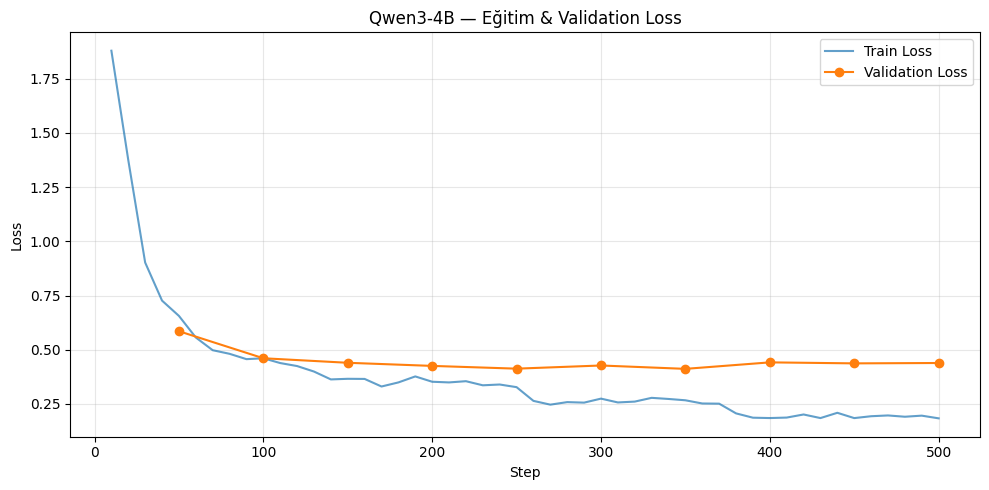

Son Train Loss : 0.1836
Son Val Loss   : 0.4389


In [8]:
# ── Qwen3 Sonuçları ───────────────────────────────────────────────────────────
plot_training_history(qwen_trainer.state.log_history, "Qwen3-4B")

**Tüm Modeli Kaydeder**

In [ ]:
# ── Qwen3 Kaydetme ────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

QWEN_SAVE_DIR = "/content/drive/MyDrive/QWEN3_finetuned"

# Unsloth ile kaydetme — merged_16bit orijinal notebookun yöntemi
qwen_model.save_pretrained_merged(QWEN_SAVE_DIR, qwen_tokenizer, save_method="merged_16bit")
print(f"Qwen3 kaydedildi: {QWEN_SAVE_DIR}")

# Validation metriklerini kaydet (karşılaştırma için)
qwen_metrics = {e["step"]: e["eval_loss"] for e in qwen_trainer.state.log_history if "eval_loss" in e}
with open("/content/drive/MyDrive/qwen3_val_metrics.json", "w") as f:
    json.dump(qwen_metrics, f, indent=2)
print("Validation metrikleri kaydedildi ✓")

**Sadece Ağırlıkları Kaydeder**

In [9]:
# ── Qwen3 Kaydetme ────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

QWEN_SAVE_DIR = "/content/drive/MyDrive/QWEN3_finetuned"
Path(QWEN_SAVE_DIR).mkdir(parents=True, exist_ok=True)

qwen_model.save_pretrained(QWEN_SAVE_DIR)   # LoRA ağırlıkları
qwen_tokenizer.save_pretrained(QWEN_SAVE_DIR)
print(f"Qwen3 kaydedildi: {QWEN_SAVE_DIR}")

# Validation metriklerini kaydet (karşılaştırma için)
qwen_metrics = {e["step"]: e["eval_loss"] for e in qwen_trainer.state.log_history if "eval_loss" in e}
with open("/content/drive/MyDrive/qwen3_val_metrics.json", "w") as f:
    json.dump(qwen_metrics, f, indent=2)
print("Validation metrikleri kaydedildi ✓")

Mounted at /content/drive
Qwen3 kaydedildi: /content/drive/MyDrive/QWEN3_finetuned
Validation metrikleri kaydedildi ✓


## 4. Model 2: Llama-3.2-3B Fine-Tuning (Unsloth)

**Ön koşul:** HuggingFace'te Meta Llama lisansını onaylamalısın →  
https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct  
Sonra: `!huggingface-cli login`

In [10]:
# ── RAM Temizliği (Qwen'den önce) ────────────────────────────────────────────
import gc
del qwen_model, qwen_trainer, qwen_tokenizer
gc.collect()
torch.cuda.empty_cache()
print(f"GPU belleği temizlendi ✓")
print(f"Serbest VRAM: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved()) / 1e9:.1f} GB")

GPU belleği temizlendi ✓
Serbest VRAM: 14.8 GB


In [ ]:
# ── Llama Model Yükleme (Unsloth) ────────────────────────────────────────────
LLAMA_MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"

print(f"Yükleniyor: {LLAMA_MODEL_NAME}")

llama_model, llama_tokenizer = FastLanguageModel.from_pretrained(
    model_name     = LLAMA_MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,  # Qwen ile aynı
    load_in_4bit   = True,
    dtype          = None,
)

llama_model = FastLanguageModel.get_peft_model(
    llama_model,
    r              = LORA_R,          # Qwen ile aynı LoRA ayarları
    lora_alpha     = LORA_ALPHA,
    target_modules = LORA_TARGET_MODULES,
    lora_dropout   = LORA_DROPOUT,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",
    random_state   = 42,
)

llama_model.print_trainable_parameters()

In [ ]:
# ── Llama Eğitim ──────────────────────────────────────────────────────────────
llama_trainer = SFTTrainer(
    model         = llama_model,
    tokenizer     = llama_tokenizer,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,    # ← Aynı validation seti
    args          = get_training_args("./llama_finetuned"),
)

start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
print(f"Eğitim öncesi ayrılan VRAM: {start_gpu_memory} GB")
print("Llama-3.2-3B eğitimi başlıyor...")

llama_result = llama_trainer.train()

used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
print(f"\nLlama eğitimi tamamlandı ✓")
print(f"Süre         : {llama_result.metrics['train_runtime']:.1f} sn")
print(f"Peak VRAM    : {used_memory} GB")

In [ ]:
# ── Llama Sonuçları ───────────────────────────────────────────────────────────
plot_training_history(llama_trainer.state.log_history, "Llama-3.2-3B")

**Tüm Modeli Kaydeder**

In [ ]:
# ── Llama Kaydetme ────────────────────────────────────────────────────────────
LLAMA_SAVE_DIR = "/content/drive/MyDrive/LLAMA_finetuned"
llama_model.save_pretrained_merged(LLAMA_SAVE_DIR, llama_tokenizer, save_method="merged_16bit")
print(f"Llama kaydedildi: {LLAMA_SAVE_DIR}")

llama_metrics = {e["step"]: e["eval_loss"] for e in llama_trainer.state.log_history if "eval_loss" in e}
with open("/content/drive/MyDrive/llama_val_metrics.json", "w") as f:
    json.dump(llama_metrics, f, indent=2)
print("Validation metrikleri kaydedildi ✓")

**Sadece Ağırlıkları Kaydeder**

In [ ]:
# ── Llama Kaydetme ────────────────────────────────────────────────────────────
LLAMA_SAVE_DIR = "/content/drive/MyDrive/LLAMA_finetuned"
Path(LLAMA_SAVE_DIR).mkdir(parents=True, exist_ok=True)

llama_model.save_pretrained(LLAMA_SAVE_DIR)
llama_tokenizer.save_pretrained(LLAMA_SAVE_DIR)
print(f"Llama kaydedildi: {LLAMA_SAVE_DIR}")

llama_metrics = {e["step"]: e["eval_loss"] for e in llama_trainer.state.log_history if "eval_loss" in e}
with open("/content/drive/MyDrive/llama_val_metrics.json", "w") as f:
    json.dump(llama_metrics, f, indent=2)
print("Validation metrikleri kaydedildi ✓")

**-QWEN 2.5 FINE TUNING DENEMESİ**

In [11]:
# ── QWEN 2.5 Yükleme ────────────────────────────────────────────────────────────

QWEN25_MODEL_NAME="Qwen/Qwen2.5-3B-Instruct"

qwen25_model, qwen25_tokenizer = FastLanguageModel.from_pretrained(
    model_name     = QWEN25_MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit   = True,          # 4-bit quantization (BnbConfig'e gerek yok)
    dtype          = None,          # Otomatik tespit (bf16 destekliyorsa bf16)
)

qwen25_model = FastLanguageModel.get_peft_model(
    qwen25_model,
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    target_modules = LORA_TARGET_MODULES,
    lora_dropout   = LORA_DROPOUT,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",  # Unsloth'a özgü, %30 daha az VRAM
    random_state   = 42,
)

qwen25_model.print_trainable_parameters()



==((====))==  Unsloth 2026.4.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


In [12]:
# ── QWEN2.5 Eğitim ──────────────────────────────────────────────────────────────
qwen25_trainer = SFTTrainer(
    model         = qwen25_model,
    tokenizer     = qwen25_tokenizer,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,    # ← Validation seti
    args          = get_training_args("./qwen25_finetuned"),
)

# VRAM durumunu göster
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
print(f"GPU: {gpu_stats.name} | VRAM: {gpu_stats.total_memory / 1e9:.1f} GB")
print(f"Eğitim öncesi ayrılan VRAM: {start_gpu_memory} GB")
print("\nQwen2.5 eğitimi başlıyor...")

qwen25_result = qwen25_trainer.train()

used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
print(f"\nQwen2.5 eğitimi tamamlandı ✓")
print(f"Süre         : {qwen25_result.metrics['train_runtime']:.1f} sn")
print(f"Peak VRAM    : {used_memory} GB")

Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/992 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/124 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


GPU: Tesla T4 | VRAM: 15.6 GB
Eğitim öncesi ayrılan VRAM: 4.541 GB

Qwen2.5 eğitimi başlıyor...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 992 | Num Epochs = 5 | Total steps = 500
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
50,0.895605,0.800024
100,0.574827,0.585949
150,0.460822,0.545252
200,0.437462,0.525908
250,0.402953,0.505358
300,0.352706,0.511571
350,0.330506,0.498529
400,0.235584,0.526719
450,0.221504,0.520644
500,0.223688,0.521533


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


Qwen2.5 eğitimi tamamlandı ✓
Süre         : 2529.6 sn
Peak VRAM    : 4.541 GB


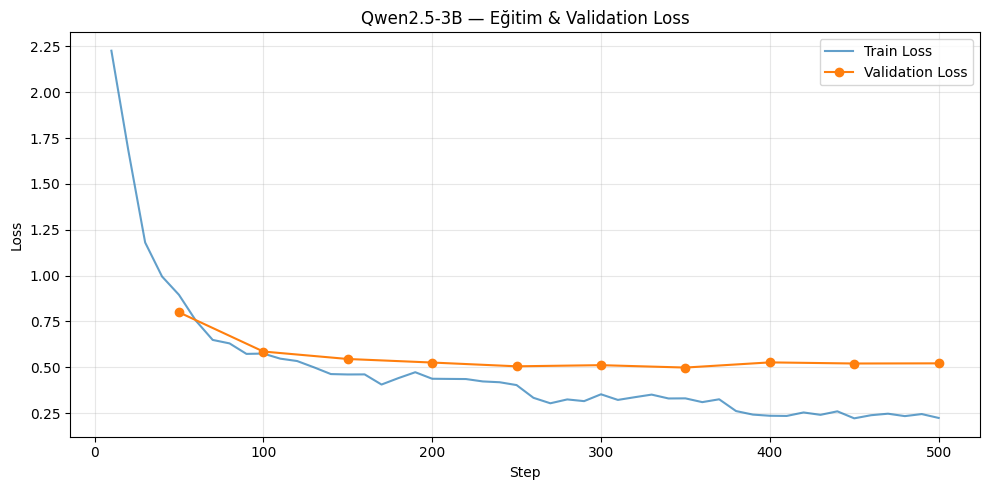

Son Train Loss : 0.2237
Son Val Loss   : 0.5215


In [13]:
plot_training_history(qwen25_trainer.state.log_history, "Qwen2.5-3B")

Sadece Ağırlıkları Kaydeder

In [14]:
# ── QWEN2.5 Kaydetme ────────────────────────────────────────────────────────────
QWEN25_SAVE_DIR = "/content/drive/MyDrive/QWEN2.5_finetuned"
Path(QWEN25_SAVE_DIR).mkdir(parents=True, exist_ok=True)

qwen25_model.save_pretrained(QWEN25_SAVE_DIR)
qwen25_tokenizer.save_pretrained(QWEN25_SAVE_DIR)
print(f"QWEN2.5 kaydedildi: {QWEN25_SAVE_DIR}")

qwen25_metrics = {e["step"]: e["eval_loss"] for e in qwen25_trainer.state.log_history if "eval_loss" in e}
with open("/content/drive/MyDrive/qwen25_val_metrics.json", "w") as f:
    json.dump(qwen25_metrics, f, indent=2)
print("Validation metrikleri kaydedildi ✓")

QWEN2.5 kaydedildi: /content/drive/MyDrive/QWEN2.5_finetuned
Validation metrikleri kaydedildi ✓


##**OPENLLAMA FINE TUNE DENEMESİ**

In [17]:
# ── RAM Temizliği (Qwen'den önce) ────────────────────────────────────────────
import gc
del qwen25_model, qwen25_trainer, qwen25_tokenizer
gc.collect()
torch.cuda.empty_cache()
print(f"GPU belleği temizlendi ✓")
print(f"Serbest VRAM: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved()) / 1e9:.1f} GB")

GPU belleği temizlendi ✓
Serbest VRAM: 14.2 GB


In [18]:
# ── OPENLLAMA YÜKLEME ────────────────────────────────────────────────────────────

OPENLLAMA_MODEL_NAME = "openlm-research/open_llama_3b"

openllama_model, openllama_tokenizer = FastLanguageModel.from_pretrained(
    model_name     = OPENLLAMA_MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit   = True,   # 4-bit quantization
    dtype          = None     # BF16 destekliyorsa otomatik seçilir
)
openllama_model = FastLanguageModel.get_peft_model(
    openllama_model,
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    target_modules = LORA_TARGET_MODULES,
    lora_dropout   = LORA_DROPOUT,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",
    random_state   = 42
)

openllama_model.print_trainable_parameters()

==((====))==  Unsloth 2026.4.4: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


pytorch_model.bin:   0%|          | 0.00/6.85G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.85G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/237 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/534k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/330 [00:00<?, ?B/s]

openlm-research/open_llama_3b does not have a padding token! Will use pad_token = <unk>.


Unsloth 2026.4.4 patched 26 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 25,425,920 || all params: 3,451,899,520 || trainable%: 0.7366


In [19]:
# ── OpenLLaMA 3B Eğitim ─────────────────────────────────────────────────────────

openllama_trainer = SFTTrainer(
    model         = openllama_model,
    tokenizer     = openllama_tokenizer,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,      # ← Validation seti
    args          = get_training_args("./openllama_3b_finetuned"),  # Kayıt yolu
)

# VRAM durumunu göster
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
print(f"GPU: {gpu_stats.name} | VRAM: {gpu_stats.total_memory / 1e9:.1f} GB")
print(f"Eğitim öncesi ayrılan VRAM: {start_gpu_memory} GB")
print("\nOpenLLaMA 3B eğitimi başlıyor...")

openllama_result = openllama_trainer.train()

used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
print(f"\nOpenLLaMA 3B eğitimi tamamlandı ✓")
print(f"Süre         : {openllama_result.metrics['train_runtime']:.1f} sn")
print(f"Peak VRAM    : {used_memory} GB")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/992 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/124 [00:00<?, ? examples/s]

GPU: Tesla T4 | VRAM: 15.6 GB
Eğitim öncesi ayrılan VRAM: 4.541 GB

OpenLLaMA 3B eğitimi başlıyor...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 992 | Num Epochs = 5 | Total steps = 500
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 25,425,920 of 3,451,899,520 (0.74% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
50,0.922375,0.829302
100,0.541554,0.541003
150,0.440780,0.499699
200,0.417591,0.470169
250,0.389892,0.454461
300,0.350810,0.452299
350,0.320643,0.435871
400,0.243151,0.451203
450,0.222544,0.449300
500,0.221386,0.440532


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


OpenLLaMA 3B eğitimi tamamlandı ✓
Süre         : 4362.5 sn
Peak VRAM    : 4.623 GB


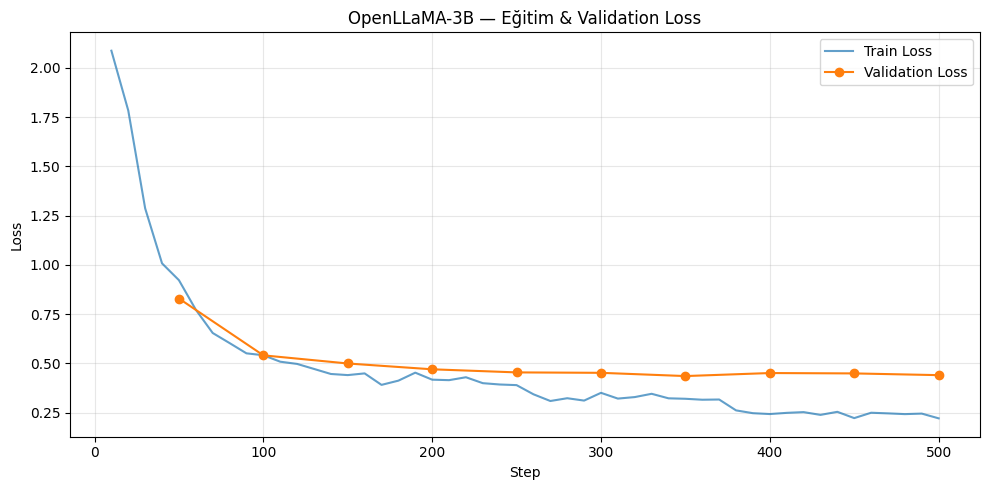

Son Train Loss : 0.2214
Son Val Loss   : 0.4405


In [20]:
plot_training_history(openllama_trainer.state.log_history, "OpenLLaMA-3B")

Sadece Ağırlıkları Kaydetme

In [21]:
# ── OpenLLaMA 3B Kaydetme ─────────────────────────────────────────────────────────
from pathlib import Path
import json

OPENLLAMA_SAVE_DIR = "/content/drive/MyDrive/OpenLLaMA_3B_finetuned"
Path(OPENLLAMA_SAVE_DIR).mkdir(parents=True, exist_ok=True)

# Model ve tokenizer kaydı
openllama_model.save_pretrained(OPENLLAMA_SAVE_DIR)
openllama_tokenizer.save_pretrained(OPENLLAMA_SAVE_DIR)
print(f"OpenLLaMA 3B kaydedildi: {OPENLLAMA_SAVE_DIR}")

# Validation metriklerini kaydet (karşılaştırma için)
openllama_metrics = {
    e["step"]: e["eval_loss"]
    for e in openllama_trainer.state.log_history
    if "eval_loss" in e
}

with open("/content/drive/MyDrive/openllama_3b_val_metrics.json", "w") as f:
    json.dump(openllama_metrics, f, indent=2)
print("Validation metrikleri kaydedildi ✓")

OpenLLaMA 3B kaydedildi: /content/drive/MyDrive/OpenLLaMA_3B_finetuned
Validation metrikleri kaydedildi ✓


## 5. Model Karşılaştırması

Her iki modeli **daha önce hiç görmediği test seti** üzerinde değerlendiriyoruz.

In [ ]:
# ── Validation Loss Karşılaştırma Grafiği ─────────────────────────────────────
with open("/content/drive/MyDrive/qwen3_val_metrics.json") as f:
    qwen_val = json.load(f)
with open("/content/drive/MyDrive/llama_val_metrics.json") as f:
    llama_val = json.load(f)

qwen_steps   = [int(k) for k in qwen_val.keys()]
qwen_losses  = list(qwen_val.values())
llama_steps  = [int(k) for k in llama_val.keys()]
llama_losses = list(llama_val.values())

plt.figure(figsize=(12, 6))
plt.plot(qwen_steps,  qwen_losses,  marker="o", label="Qwen3-4B",     linewidth=2)
plt.plot(llama_steps, llama_losses, marker="s", label="Llama-3.2-3B", linewidth=2)
plt.xlabel("Eğitim Adımı", fontsize=12)
plt.ylabel("Validation Loss", fontsize=12)
plt.title("Model Karşılaştırması — Validation Loss", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/model_comparison.png", dpi=150)
plt.show()

print(f"Son Validation Loss:")
print(f"  Qwen3-4B     : {qwen_losses[-1]:.4f}  (perplexity: {math.exp(qwen_losses[-1]):.2f})")
print(f"  Llama-3.2-3B : {llama_losses[-1]:.4f}  (perplexity: {math.exp(llama_losses[-1]):.2f})")

## 6. Örnek Çıktı Karşılaştırması (Nitel)

In [ ]:
# ── Inference Yardımcısı (Unsloth ile hızlı inference) ───────────────────────
def generate_response(model, tokenizer, prompt_text, max_new_tokens=200):
    # Unsloth inference modu — 2x daha hızlı
    FastLanguageModel.for_inference(model)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens   = max_new_tokens,
            do_sample        = False,
            pad_token_id     = tokenizer.eos_token_id
        )
    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)

# Test setinden örnek al
sample_idx  = random.randint(0, len(test_dataset) - 1)
sample_text = test_dataset[sample_idx]["text"]
prompt      = sample_text.split("### Response:")[0] + "### Response:\n"
reference   = sample_text.split("### Response:")[1].strip()

print("── PROMPT ──")
print(prompt)
print("── REFERANS CEVAP ──")
print(reference)

# Modeller Drive'dan yüklüyse:
# qwen_model, qwen_tokenizer = FastLanguageModel.from_pretrained(QWEN_SAVE_DIR, max_seq_length=MAX_SEQ_LENGTH, load_in_4bit=True)
# llama_model, llama_tokenizer = FastLanguageModel.from_pretrained(LLAMA_SAVE_DIR, max_seq_length=MAX_SEQ_LENGTH, load_in_4bit=True)

# print("\n── QWEN3 CEVABI ──")
# print(generate_response(qwen_model, qwen_tokenizer, prompt))

# print("\n── LLAMA CEVABI ──")
# print(generate_response(llama_model, llama_tokenizer, prompt))